Prehension (Clean Clusters): The clustering algorithm (e.g., K-Means) successfully grouped the movements by distance. This means for the prehension (grasping) task, the target distance was the single most dominant factor influencing the overall shape of the movement.

Aiming (Messy Clusters): The algorithms couldn't agree on how to group the data (low ARI score), and the groups they created were a random mix of all distances. It suggests that for aiming, movement strategies are more complex. The distance isn't the only thing that matters. Something else perhaps the visual condition (visCond) or just individual habits is creating overlapping, less distinct movement patterns.

Visual Illusions (Misleading Clusters): we got a perfect agreement score (ARI = 1.0), but the feedback correctly points out this is a statistical illusion. Both algorithms simply separated a few extreme outliers from one giant cluster of data. The PCA plot confirms this. The insight here is that the type of visual illusion presented did not create distinct, separable movement strategies. Most of the trials were kinematically very similar to each other.

Key Observation 3: (Visual Illusions)
What it says: The model predicted the illusion type with ~74.5% accuracy.

The "Why": The most important features were related to the final grip orientation (FGOt, FGOf). Any effect of a visual illusion on a grasping action would logically appear in the final, delicate shaping and positioning of the fingers, not necessarily in the broad speed or acceleration of the arm.

1. Cluster the Data: For each experiment, the code first performs unsupervised clustering (using PCA for dimensionality reduction and KMeans with k=2) to find two distinct groups of movements based on their entire kinematic profile.

2. Define a "Persona": We selected a handful of key, interpretable kinematic features (like movTime, MVel, pathLength) that can be used to describe a movement's style.

3. Calculate the Average Profile: The code then calculates the average value of these "persona" features for all the movements within each cluster. This gives us the mean kinematic profile, or "persona," for each group.

4. Scale for Comparison: To plot these different metrics on the same chart, the mean values are scaled from 0 to 1 using MinMaxScaler. A value of 1.0 means that cluster has the highest score on that feature, while 0.0 means it has the lowest.

5. Visualize: Finally, it plots these scaled personas on a radar chart, where each axis is a kinematic feature. This creates a unique visual "fingerprint" for each movement strategy.



In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [33]:
df_prehension = pd.read_csv("../../data/02_processed/prehension_master_dataset.csv")

In [34]:
# Use the full kinematic feature set for clustering
kinematic_features = df_prehension.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
X = df_prehension[kinematic_features]
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=47).fit_transform(X_scaled)

In [35]:
# Perform clustering for k=2
kmeans_sil = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_prehension['grip_strategy'] = kmeans_sil.fit_predict(X_pca)

# --- Persona Analysis Starts Here ---


In [36]:
# Define the features that will form "persona"
persona_features = [
    'movTime', 'MVel', 'MAcc', 'MDec', 
    'pathLength', 'MGA'
]

# Calculate the mean of these features for each cluster
cluster_personas = df_prehension.groupby('grip_strategy')[persona_features].mean()

print("Cluster Personas (Mean Values):")
print(cluster_personas)

Cluster Personas (Mean Values):
                movTime      MVel      MAcc      MDec  pathLength       MGA
grip_strategy                                                              
0              3.901114  1.332959  9.215102 -6.672615    0.518491  0.109519
1              3.735345  0.911320  7.570538 -4.922043    0.775837  0.108124



Scaled Personas (for plotting):
               movTime  MVel  MAcc  MDec  pathLength  MGA
grip_strategy                                            
0                  1.0   1.0   1.0   0.0         0.0  1.0
1                  0.0   0.0   0.0   1.0         1.0  0.0


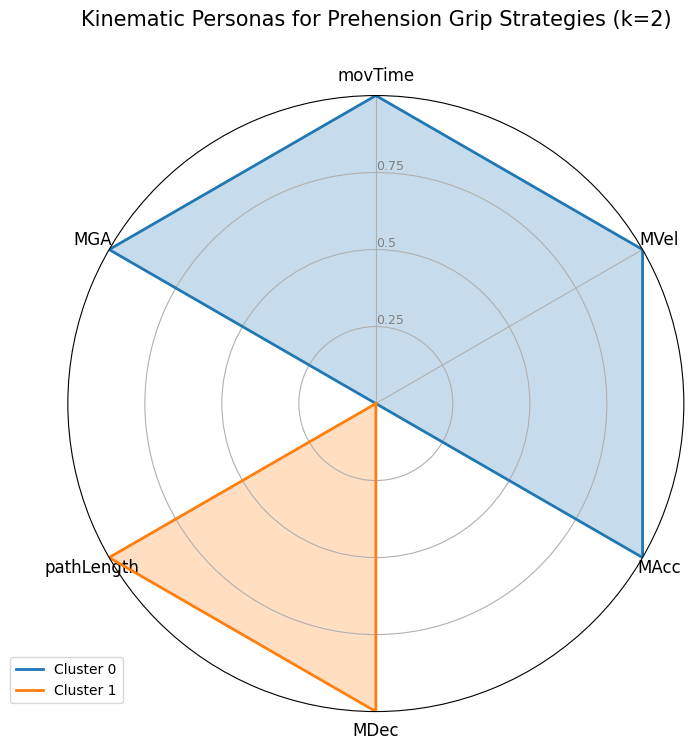

In [37]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.plotting import plot_radar_chart

scaler = MinMaxScaler()
personas_scaled = pd.DataFrame(scaler.fit_transform(cluster_personas),
                               index=cluster_personas.index,
                               columns=cluster_personas.columns)

print("\nScaled Personas (for plotting):")
print(personas_scaled)

# Generate the plot
plot_radar_chart(
    df=personas_scaled,
    title="Kinematic Personas for Prehension Grip Strategies (k=2)",
    save_path="../../results/figures/prehension_cluster_personas_k2.png"
)

# Here we are using minMax scaler to find min. and max. b/w two clusters. If cluster 0 has the higher mean for movTime, it gets 1.0, and cluster 1 gets 0.0.
# If cluster 1 has the higher mean for MDec, it gets 1.0, and cluster 0 gets 0.0.

Cluster 0 (Short Grasp)represents a fast, forceful, and wide-grip strategy characterized by higher velocity and acceleration, shorter paths, and larger grip apertures.

Cluster 1 (Long Reach)represents a slower, more cautious, and narrow-grip strategy with higher deceleration, longer paths, and smaller grip apertures."

Why use MinMaxScaler?
1. Radar charts:
    * Features like velocity or acceleration can have very different scales.
    * Scaling to [0,1] puts all features on equal footing, making the radar chart meaningful.

2. Machine learning models (in other contexts):
    * Some models (like KNN, gradient descent-based methods) are sensitive to feature scale.

# Aiming Dataset (k=2)

In [38]:
from src.plotting import plot_radar_chart
from sklearn.preprocessing import MinMaxScaler

In [39]:
# persona_features = [
#     'movTime', 'MVel', 'MAcc', 'MDec', 
#     'pathLength', 'MGA' 
# ]

# persona_features_aiming = ['movTime', 'MVel', 'MAcc', 'MDec', 'pathLength', 'FGA']


In [40]:
df_aiming = pd.read_csv("../../data/02_processed/aiming_master_dataset.csv")


In [41]:
persona_features_aiming = [
    'movTime', 'FVel', 'MAcc', 'MDec', 
    'pathLength', 'FGA'
]

In [42]:
# Re-run clustering to get labels
kinematic_features_aiming = df_aiming.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
X_aiming = df_aiming[kinematic_features_aiming]
X_scaled_aiming = StandardScaler().fit_transform(X_aiming)
X_pca_aiming = PCA(n_components=59).fit_transform(X_scaled_aiming)

kmeans_aiming = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_aiming['aiming_strategy_k2'] = kmeans_aiming.fit_predict(X_pca_aiming)


In [43]:
personas_aiming_k2 = df_aiming.groupby('aiming_strategy_k2')[persona_features_aiming].mean()


In [44]:
cluster_personas_aiming = df_aiming.groupby('aiming_strategy_k2')[persona_features_aiming].mean()
print("Aiming Cluster Personas (Mean Values):")
print(cluster_personas_aiming)


Aiming Cluster Personas (Mean Values):
                     movTime      FVel      MAcc      MDec  pathLength  \
aiming_strategy_k2                                                       
0                   3.969381  0.041209  5.563998 -6.055619    0.568829   
1                   3.289771  0.038796  5.608195 -5.975945    0.503655   

                         FGA  
aiming_strategy_k2            
0                   0.072144  
1                   0.085201  


Aiming Personas (k=2) - Scaled Means:
                    movTime  FVel  MAcc  MDec  pathLength  FGA
aiming_strategy_k2                                            
0                       1.0   1.0   0.0   0.0         1.0  0.0
1                       0.0   0.0   1.0   1.0         0.0  1.0


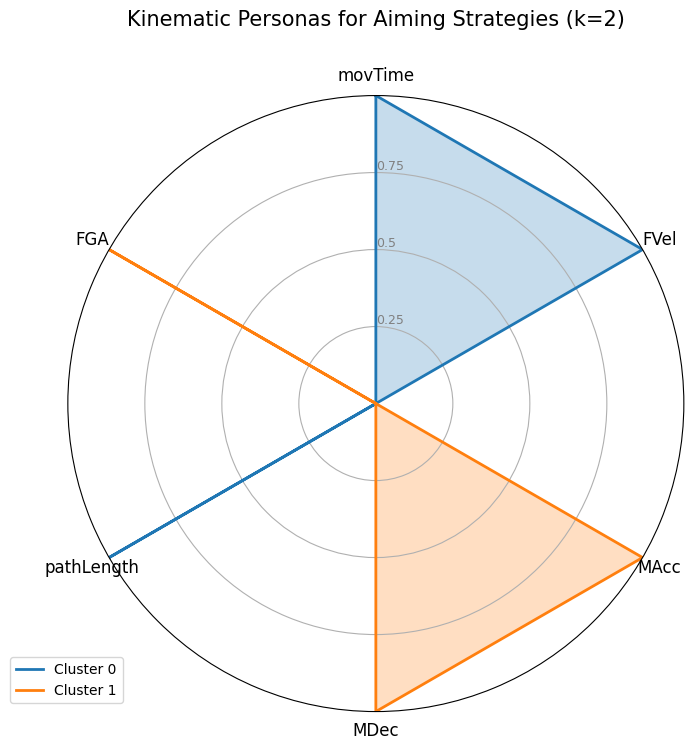

In [45]:
# Scale and plot
scaler_aiming = MinMaxScaler()
personas_scaled_aiming_k2 = pd.DataFrame(scaler_aiming.fit_transform(personas_aiming_k2),
                               index=personas_aiming_k2.index,
                               columns=personas_aiming_k2.columns)

print("Aiming Personas (k=2) - Scaled Means:")
print(personas_scaled_aiming_k2)

plot_radar_chart(
    df=personas_scaled_aiming_k2,
    title="Kinematic Personas for Aiming Strategies (k=2)",
    save_path="../../results/figures/aiming_cluster_personas_k2.png"
)

# rep: fga with mga, fval with mvel

Cluster 1 (Orange) - "The Ballistic Pointer": This strategy scores high on MAcc and MDec (acceleration/deceleration). It's a very forceful, rapid, and short movement, defined by its high dynamics.

Cluster 0 (Blue) - "The Deliberate Pointer": This strategy is the opposite. It's defined by a longer movTime, a longer pathLength, and a higher FVel (Final Velocity). This describes a smoother, less aggressive, and longer pointing action.

Unlike the prehension task, the clusters here are not just about distance. They have separated two distinct dynamic styles of pointing. This could reflect subject preference or perhaps a difference in strategy for different visual conditions that you could investigate later.



## Updated Personas

In [46]:
# persona_features_aiming = [
#     'movTime', 'MVel_y', 'MAcc', 'MDec', 
#     'pathLength', 'MGA_y'
# ]

In [47]:
# # Re-run clustering to get labels
# kinematic_features_aiming = df_aiming.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN']).columns
# X_aiming = df_aiming[kinematic_features_aiming]
# X_scaled_aiming = StandardScaler().fit_transform(X_aiming)
# X_pca_aiming = PCA(n_components=59).fit_transform(X_scaled_aiming)

# kmeans_aiming = KMeans(n_clusters=2, random_state=42, n_init='auto')
# df_aiming['aiming_strategy_k2'] = kmeans_aiming.fit_predict(X_pca_aiming)


In [48]:
# personas_aiming_k2 = df_aiming.groupby('aiming_strategy_k2')[persona_features_aiming].mean()


In [49]:
# # Scale and plot
# scaler_aiming = MinMaxScaler()
# personas_scaled_aiming_k2 = pd.DataFrame(scaler_aiming.fit_transform(personas_aiming_k2),
#                                index=personas_aiming_k2.index,
#                                columns=personas_aiming_k2.columns)

# print("Aiming Personas (k=2) - Scaled Means:")
# print(personas_scaled_aiming_k2)

# plot_radar_chart(
#     df=personas_scaled_aiming_k2,
#     title="Kinematic Personas for Aiming Strategies (k=2)",
#     # save_path="../../results/figures/aiming_cluster_personas_k2.png"
# )

# Refining Visual Illusions

In [50]:
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")

persona_features_illusions = ['movTime', 'MVel', 'MAcc', 'MDec', 'pathLength', 'FGA']

In [51]:
# Re-run clustering
kinematic_features_illusions = df_illusions.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN', 'targetSize']).columns
X_illusions = df_illusions[kinematic_features_illusions]
X_scaled_illusions = StandardScaler().fit_transform(X_illusions)
X_pca_illusions = PCA(n_components=50).fit_transform(X_scaled_illusions)

kmeans_illusions = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_illusions['illusion_strategy_k2'] = kmeans_illusions.fit_predict(X_pca_illusions)


In [52]:
# Calculate personas
if 'FGA' not in df_illusions.columns:
    print("FGA not in illusions dataset, using 'FAcc' instead for persona.")
    persona_features_illusions = ['movTime', 'MVel', 'MAcc', 'MDec', 'pathLength', 'FAcc']


personas_illusions_k2 = df_illusions.groupby('illusion_strategy_k2')[persona_features_illusions].mean()


In [53]:
print("Visual Illusion Cluster Personas (Mean Values):")
print(personas_illusions_k2)


Visual Illusion Cluster Personas (Mean Values):
                       movTime      MVel       MAcc       MDec  pathLength  \
illusion_strategy_k2                                                         
0                     0.769257  0.771264   4.756954  -3.340616    0.314877   
1                     0.733333  1.825814  39.876845 -17.726557    0.456315   

                           FGA  
illusion_strategy_k2            
0                     0.067079  
1                     0.149609  


Visual Illusion Personas (k=2) - Scaled Means:
                      movTime  MVel  MAcc  MDec  pathLength  FGA
illusion_strategy_k2                                            
0                         1.0   0.0   0.0   1.0         0.0  0.0
1                         0.0   1.0   1.0   0.0         1.0  1.0


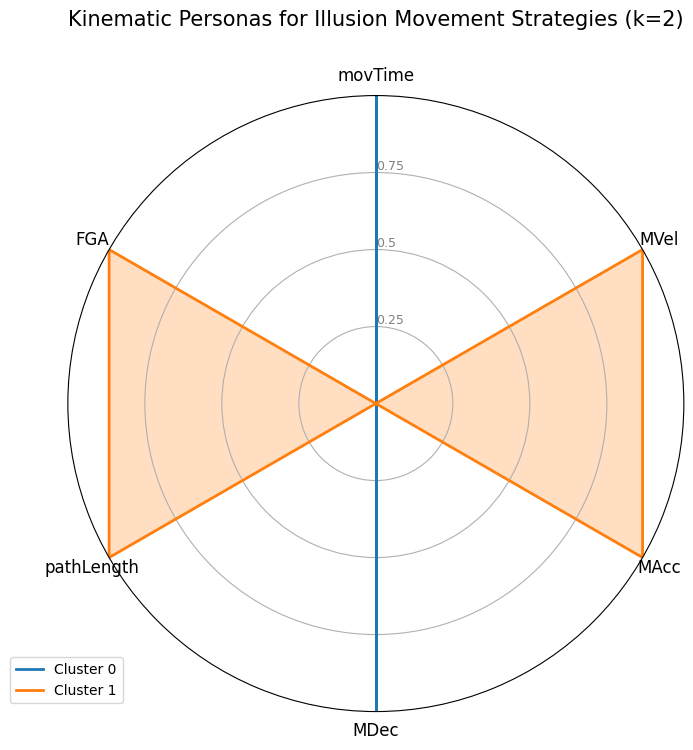

In [54]:
# Scale and plot
scaler_illusions = MinMaxScaler()
personas_scaled_illusions_k2 = pd.DataFrame(scaler_illusions.fit_transform(personas_illusions_k2),
                               index=personas_illusions_k2.index,
                               columns=personas_illusions_k2.columns)
print("Visual Illusion Personas (k=2) - Scaled Means:")
print(personas_scaled_illusions_k2)


plot_radar_chart(
    df=personas_scaled_illusions_k2,
    title="Kinematic Personas for Illusion Movement Strategies (k=2)",
    save_path="../../results/figures/illusions_cluster_personas_k2.png"
)

# grip orien, mga
# rep: movtime, fga

### Updated personas

In [55]:
# df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")

In [56]:
# kinematic_features_illusions = df_illusions.select_dtypes(include=np.number).drop(columns=['subjName', 'trialN', 'targetSize']).columns


In [57]:
# X_illusions = df_illusions[kinematic_features_illusions]
# X_scaled_illusions = StandardScaler().fit_transform(X_illusions)
# X_pca_illusions = PCA(n_components=50).fit_transform(X_scaled_illusions)

# # Run clustering
# kmeans_illusions = KMeans(n_clusters=2, random_state=42, n_init='auto')
# df_illusions['illusion_strategy_k2'] = kmeans_illusions.fit_predict(X_pca_illusions)


In [58]:
# # Persona features - using MGA instead of FGA
# persona_features_illusions = [
#     'movTime', 'MVel', 'MAcc', 'MDec', 
#     'pathLength', 'MGA'
# ]

# # Calculate personas
# personas_illusions_k2 = df_illusions.groupby('illusion_strategy_k2')[persona_features_illusions].mean()

# # Scale
# scaler_illusions = MinMaxScaler()
# personas_scaled_illusions_k2 = pd.DataFrame(
#     scaler_illusions.fit_transform(personas_illusions_k2),
#     index=personas_illusions_k2.index,
#     columns=personas_illusions_k2.columns
# )

# print("Visual Illusion Personas (k=2) - Scaled Means:")
# print(personas_scaled_illusions_k2)

# # Plot
# plot_radar_chart(
#     df=personas_scaled_illusions_k2,
#     title="Kinematic Personas for Illusion Movement Strategies (k=2)",
#     # save_path="../../results/figures/illusions_cluster_personas_k2.png"
# )


Cluster 1 (Orange) - "The Expansive Reach": This persona scores high on MVel, MAcc, pathLength, and FGA (Final Grip Aperture). This is a fast, powerful, long-reaching movement that ends with a wide, open grip.

Cluster 0 (Blue) - "The Cautious Grasp": This persona is the complete opposite. It's defined by a long movTime (i.e., it's slow) and a high MDec (a more pronounced and controlled deceleration phase).

The clustering has uncovered two distinct endogenous strategies for dealing with the uncertainty of the visual illusion. These strategies are not tied to an obvious external factor like target distance. Instead, they likely represent two different mindsets:

One strategy is to move quickly and decisively, opening the hand wide to ensure a successful grasp despite the illusion ("Expansive Reach").

The other strategy is to be slow, careful, and deliberate, taking extra time to slow down and ensure accuracy ("Cautious Grasp").

### Summary of A and B

Created a Curated Feature Set: We systematically identified and removed all "leaky" features related to the final XYZ position of the hand and fingers. This produced a clean, curated feature set containing only true kinematic and dynamic information (e.g., velocity, acceleration, path length, grip aperture). We then re-trained and re-evaluated our RandomForestClassifier models on this curated data.

Developed "Cluster Personas": We applied KMeans clustering (with k=2) to each dataset to identify the two most dominant movement strategies. Then, for each cluster, we calculated the average profile across key kinematic variables and visualized them using radar plots. This gave each abstract cluster a distinct and interpretable "fingerprint."

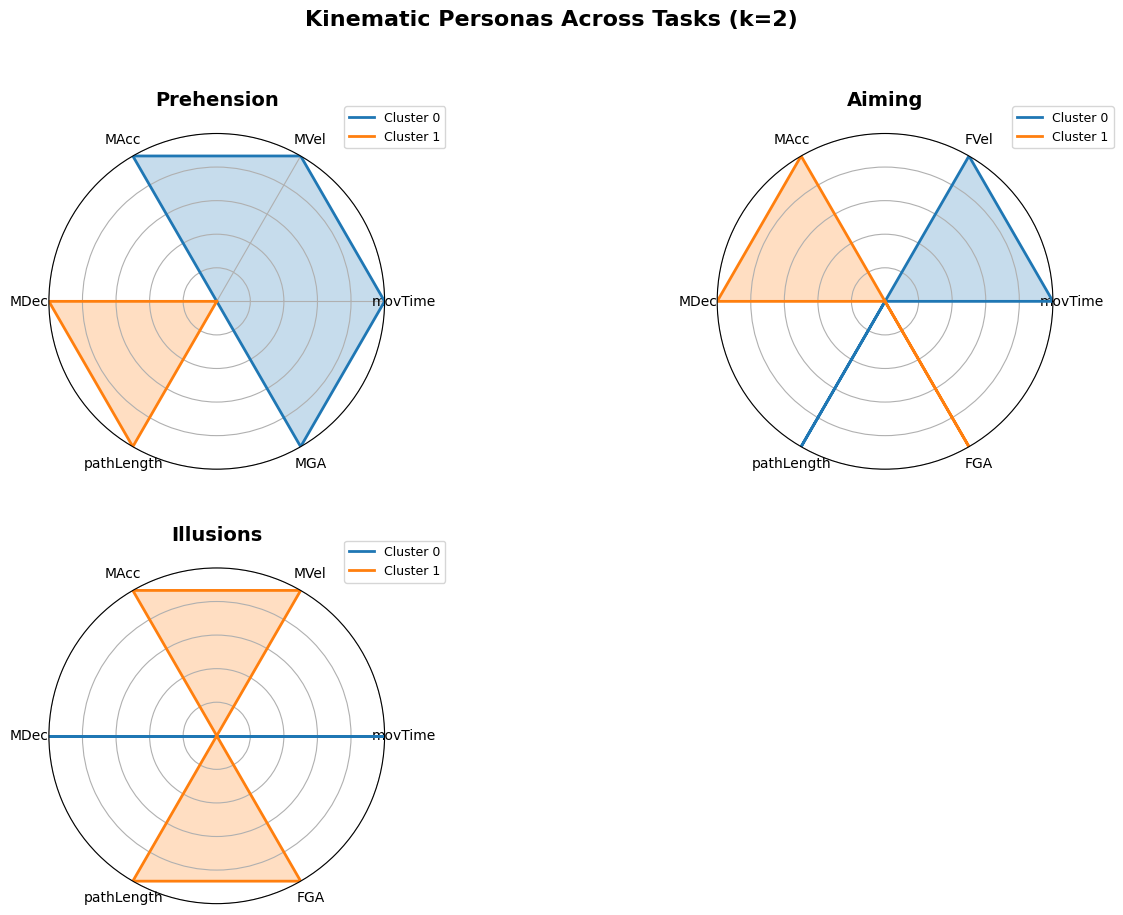

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Put all your scaled cluster personas here
datasets = [
    (personas_scaled, "Prehension"),
    (personas_scaled_aiming_k2, "Aiming"),
    (personas_scaled_illusions_k2, "Illusions")
]

# Create subplot grid: 2 rows, 2 cols (last one empty)
fig, axes = plt.subplots(2, 2, subplot_kw=dict(polar=True), figsize=(14, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, (df_scaled, title) in enumerate(datasets):
    ax = axes[i]
    categories = df_scaled.columns
    N = len(categories)

    # Angles for radar
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    # Plot each cluster
    for idx in df_scaled.index:
        values = df_scaled.loc[idx].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=f"Cluster {idx}")
        ax.fill(angles, values, alpha=0.25)

    # Formatting
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_yticklabels([])  # remove radial labels for cleaner look
    ax.set_title(title, size=14, weight="bold", pad=20)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), fontsize=9)

# Remove the last empty subplot (bottom right)
fig.delaxes(axes[-1])

# Global title & layout
plt.suptitle("Kinematic Personas Across Tasks (k=2)", size=16, weight="bold", y=0.95)
plt.tight_layout(pad=4.0)
# plt.savefig("../../results/figures/all_strategies_radar_grid.png", dpi=300, bbox_inches="tight")
plt.show()


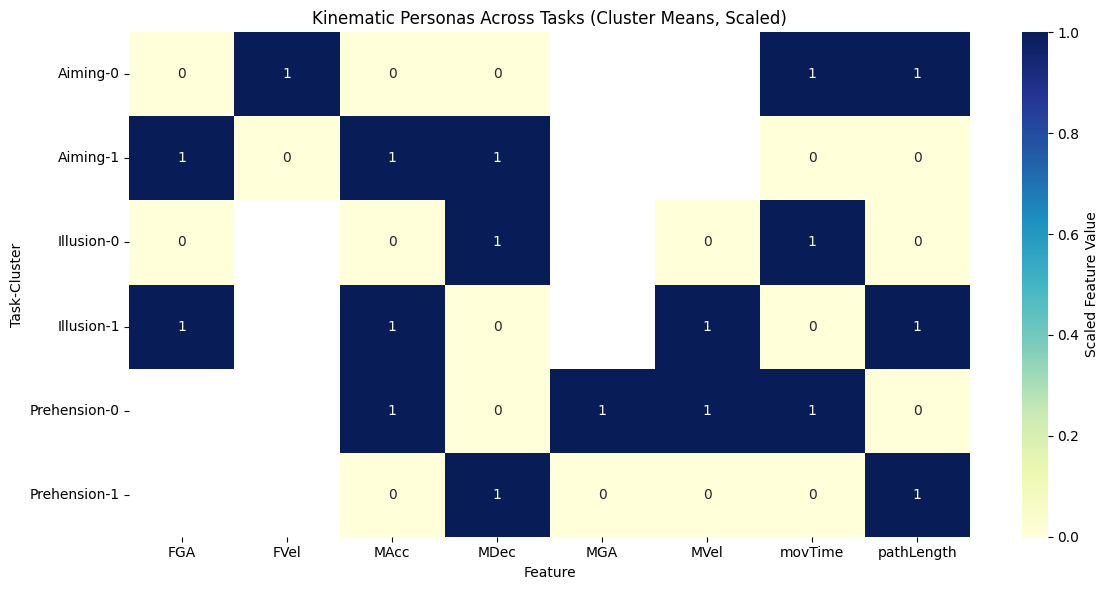

In [60]:
import seaborn as sns

# Combine datasets with clear labels
preh = personas_scaled.copy()
preh["Task"] = "Prehension"

aim = personas_scaled_aiming_k2.copy()
aim["Task"] = "Aiming"

illu = personas_scaled_illusions_k2.copy()
illu["Task"] = "Illusion"

combined = pd.concat([preh, aim, illu])
combined["Cluster"] = combined.index.astype(str)
combined = combined.reset_index(drop=True)

# Melt for heatmap
melted = combined.melt(id_vars=["Task", "Cluster"], var_name="Feature", value_name="Score")

plt.figure(figsize=(12, 6))
sns.heatmap(
    melted.pivot_table(index=["Task","Cluster"], columns="Feature", values="Score"),
    cmap="YlGnBu", annot=True, cbar_kws={'label': 'Scaled Feature Value'}
)
plt.title("Kinematic Personas Across Tasks (Cluster Means, Scaled)")
plt.tight_layout()
# plt.savefig("../../results/figures/all_strategies_heatmap.png", dpi=300)
plt.show()
